# SDP Channel Discrimination with Choi Matrices

**Agent-3 deliverable.** This notebook studies binary quantum-channel discrimination using the Choi representation and semidefinite programming.

Shared palette used below: `#2E86AB`, `#F18F01`, `#C73E1D`, `#6A994E`, `#5B2A86`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sdp_tools as sdp

np.random.seed(42)
PALETTE = ["#2E86AB", "#F18F01", "#C73E1D", "#6A994E", "#5B2A86"]
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 1. Problem Statement

Given one unknown use of either channel $\mathcal{E}_0$ or $\mathcal{E}_1$ with equal prior probability, the optimal success probability is

$$p_{\mathrm{succ}}^{\max}=\frac{1}{2}+\frac{1}{4}\|\mathcal{E}_0-\mathcal{E}_1\|_\diamond.$$

The diamond norm matters because the best input may be entangled with a reference system.  In Kraus form that is awkward to optimize over directly; in Choi form it becomes an SDP.

## 2. SDP Formulation

For the Hermiticity-preserving map $\Phi=\mathcal{E}_0-\mathcal{E}_1$ with Choi matrix $C_\Phi$, one primal form of Watrous's SDP is

$$\begin{aligned}
\text{maximize } & \langle C_\Phi, W\rangle \\
\text{subject to }& -\rho\otimes I_B \preceq W \preceq \rho\otimes I_B,\\
& \rho\succeq 0,\quad \mathrm{Tr}(\rho)=1,\quad W=W^\dagger.
\end{aligned}$$

The tensor order is input first, output second, matching the project convention $C_\mathcal{E}=\sum_{ij}|i\rangle\langle j|\otimes\mathcal{E}(|i\rangle\langle j|)$.

## 3. CVXPY Implementation Check

The module uses CVXPY Hermitian variables.  It prefers MOSEK if available, then CLARABEL, and otherwise SCS.  Small tolerance-level differences across solvers are expected, so the solver name is printed with the representative SDP check below.


In [2]:
p0, p1 = 0.10, 0.35
bf0 = sdp.bit_flip_channel_choi(p0)
bf1 = sdp.bit_flip_channel_choi(p1)

result = sdp.solve_diamond_norm_sdp(bf0 - bf1, d_in=2, d_out=2)
sdp_value = result.value
closed_form = sdp.analytical_pauli_diamond_norm({"I": 1-p0, "X": p0}, {"I": 1-p1, "X": p1})

print(f"Solver:                    {result.solver} ({result.status})")
print(f"Bit-flip SDP diamond norm: {sdp_value:.6f}")
print(f"Bit-flip closed form:      {closed_form:.6f}")
print(f"Success probability:       {0.5 + 0.25 * sdp_value:.6f}")


Solver:                    CLARABEL (optimal)
Bit-flip SDP diamond norm: 0.500000
Bit-flip closed form:      0.500000
Success probability:       0.625000


## 4. Case Studies

### Case A: Depolarizing Channels

For qubits, $D_p(\rho)=(1-p)\rho+pI/2$ and
$$\|D_p-D_q\|_\diamond=\frac{3}{2}|p-q|.$$

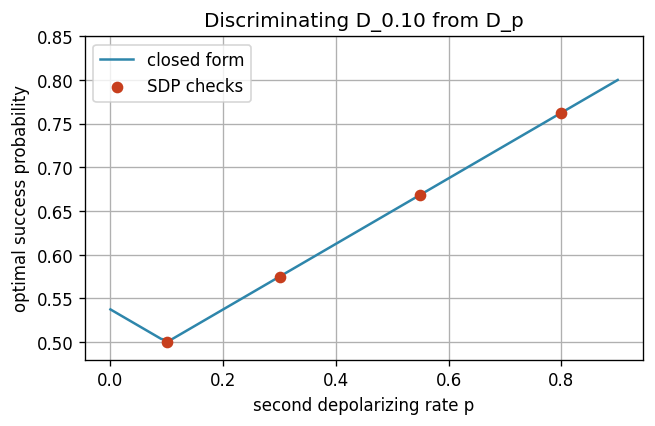

In [3]:
p_reference = 0.10
p_values = np.linspace(0.0, 0.9, 61)
analytic_success = [0.5 + 0.25 * sdp.analytical_depolarizing_diamond_norm(p_reference, p, 2) for p in p_values]

marker_ps = np.array([0.10, 0.30, 0.55, 0.80])
marker_success = [
    sdp.discrimination_probability(
        sdp.depolarizing_channel_choi(p_reference),
        sdp.depolarizing_channel_choi(float(p)),
    )
    for p in marker_ps
]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(p_values, analytic_success, color=PALETTE[0], label="closed form")
ax.scatter(marker_ps, marker_success, color=PALETTE[2], zorder=3, label="SDP checks")
ax.set_xlabel("second depolarizing rate p")
ax.set_ylabel("optimal success probability")
ax.set_title("Discriminating D_0.10 from D_p")
ax.set_ylim(0.48, 0.85)
ax.legend()
plt.show()

### Case B: Amplitude Damping vs. Phase Damping

Both channels have one noise parameter, but they deform the Bloch ball differently.  The SDP quantifies when those deformations are easiest to tell apart.

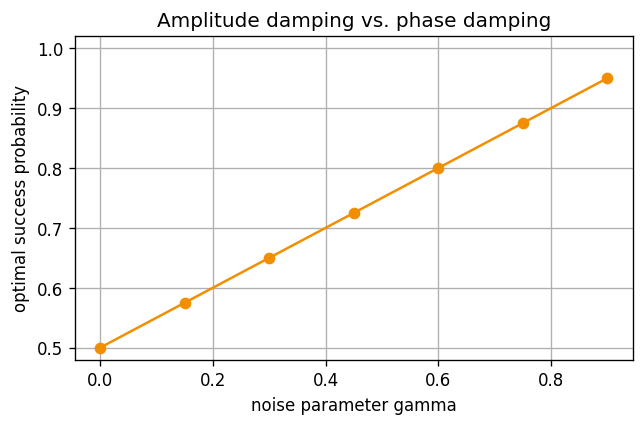

In [4]:
gammas = np.linspace(0.0, 0.9, 7)
ad_pd_success = [
    sdp.discrimination_probability(
        sdp.amplitude_damping_channel_choi(float(g)),
        sdp.phase_damping_channel_choi(float(g)),
    )
    for g in gammas
]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(gammas, ad_pd_success, marker="o", color=PALETTE[1])
ax.set_xlabel("noise parameter gamma")
ax.set_ylabel("optimal success probability")
ax.set_title("Amplitude damping vs. phase damping")
ax.set_ylim(0.48, 1.02)
plt.show()

### Case C: Coherent vs. Incoherent Noise

Here a coherent $Z$ rotation is compared with depolarizing noise.  The two errors may have superficially similar sizes but very different channel structure.

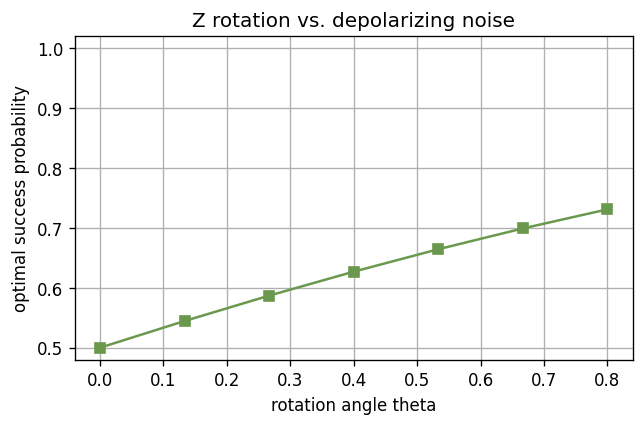

In [5]:
thetas = np.linspace(0.0, 0.8, 7)
coherent_success = [
    sdp.discrimination_probability(
        sdp.z_rotation_channel_choi(float(theta)),
        sdp.depolarizing_channel_choi(min(float(theta) / 2.0, 1.0)),
    )
    for theta in thetas
]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thetas, coherent_success, marker="s", color=PALETTE[3])
ax.set_xlabel("rotation angle theta")
ax.set_ylabel("optimal success probability")
ax.set_title("Z rotation vs. depolarizing noise")
ax.set_ylim(0.48, 1.02)
plt.show()

### Case D: Entanglement Advantage

The identity channel and the completely depolarizing qubit channel provide a compact example where an entangled reference helps.  The ancilla-assisted value is $0.875$, while the best product input reaches $0.75$.

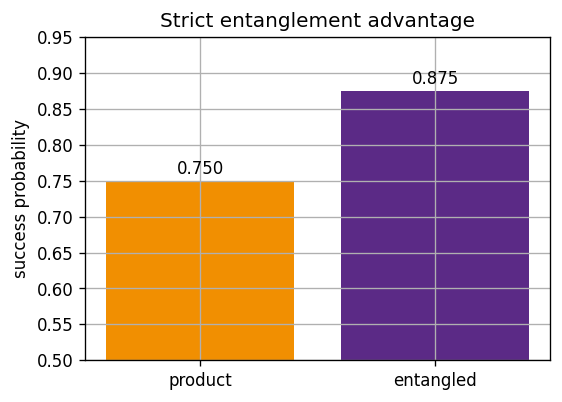

In [6]:
identity = sdp.identity_channel_choi(2)
depol_full = sdp.depolarizing_channel_choi(1.0)

entangled_success = sdp.discrimination_probability(identity, depol_full)
product_success = sdp.product_strategy_discrimination(identity, depol_full)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["product", "entangled"], [product_success, entangled_success], color=[PALETTE[1], PALETTE[4]])
ax.set_ylabel("success probability")
ax.set_title("Strict entanglement advantage")
ax.set_ylim(0.5, 0.95)
for idx, value in enumerate([product_success, entangled_success]):
    ax.text(idx, value + 0.01, f"{value:.3f}", ha="center")
plt.show()

## 5. Multi-Use Discrimination

For a parallel $n$-shot strategy, the SDP can be applied to $\mathcal{E}_0^{\otimes n}$ and $\mathcal{E}_1^{\otimes n}$.  Dimensions grow exponentially, so this is demonstrated only for small qubit examples.

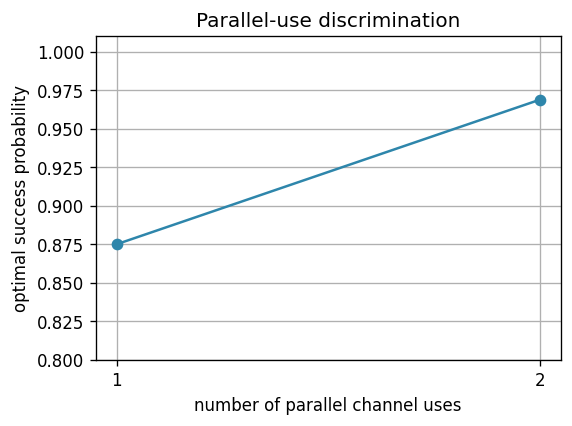

{1: np.float64(0.875), 2: np.float64(0.96875)}


In [7]:
n_values = [1, 2]
n_success = [sdp.n_shot_discrimination(identity, depol_full, n) for n in n_values]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(n_values, n_success, marker="o", color=PALETTE[0])
ax.set_xticks(n_values)
ax.set_xlabel("number of parallel channel uses")
ax.set_ylabel("optimal success probability")
ax.set_title("Parallel-use discrimination")
ax.set_ylim(0.8, 1.01)
plt.show()
print(dict(zip(n_values, np.round(n_success, 6))))

## 6. Extracting an Optimal Strategy

The SDP variable $\rho$ is the optimal input marginal on system $A$, not the full reference-system input state.  A purification of this marginal gives an ancilla-assisted input on reference $R$ and input $A$, and the sign decomposition of the resulting reference-output difference gives a Helstrom POVM.


In [8]:
rho_star = sdp.optimal_input_state(identity, depol_full)
m0, m1 = sdp.optimal_povm(identity, depol_full)

print("optimal input marginal rho:")
print(np.round(rho_star, 6))
print("trace(rho) =", np.trace(rho_star).real)
print("POVM sums to identity:", np.allclose(m0 + m1, np.eye(4)))

optimal input marginal rho:
[[0.500007+0.j 0.      +0.j]
 [0.      +0.j 0.499993+0.j]]
trace(rho) = 1.0
POVM sums to identity: True


## Complexity Notes

The main SDP variable has size $(d_{\mathrm{in}}d_{\mathrm{out}})\times(d_{\mathrm{in}}d_{\mathrm{out}})$.  Parallel $n$-shot discrimination replaces the dimensions by $d_{\mathrm{in}}^n$ and $d_{\mathrm{out}}^n$, so even qubit examples grow quickly.  The implementation is meant for clear small-dimensional experiments rather than large-scale production optimization.

References: Watrous, *Semidefinite programs for completely bounded norms* (2009); Watrous, *The Theory of Quantum Information*, Chapters 3 and 4.